In [1]:
import numpy
import matplotlib.pyplot as plt
import scipy
import scipy.linalg
%matplotlib inline

In [2]:
tspan = numpy.linspace(0, 5, 2000) #s

In [3]:
def smooth_1st(K, τ, t):
    return K * (1 - numpy.exp(-t/τ))

In [4]:
K = 5
τ = 2 #s
smooth_original = smooth_1st(K, τ, tspan)

Text(0,0.5,'y(t)')

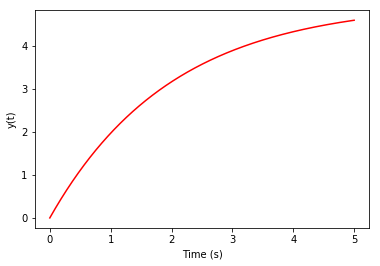

In [5]:
plt.plot(tspan, smooth_original, label = "Smooth Function", color = "red")
plt.xlabel("Time (s)")
plt.ylabel("y(t)")

In [6]:
mean = 0
variance = 0.005
stdev = numpy.sqrt(variance)
randomnoise = numpy.random.normal(mean, stdev, len(tspan))
signal = smooth_original + randomnoise

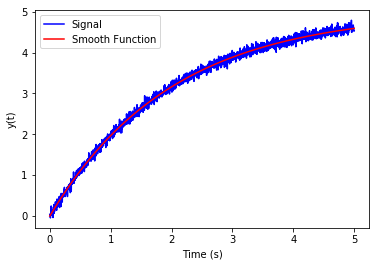

In [7]:
plt.plot(tspan, signal, label = "Signal", color = "blue")
plt.plot(tspan, smooth_original, label = "Smooth Function", color = "red")
plt.xlabel("Time (s)")
plt.ylabel("y(t)")
plt.legend(loc = "best")

In [8]:
Δt = 0.5 #s
sampletimes = numpy.arange(tspan[0], tspan[-1], Δt)

In [9]:
samplevalues = numpy.interp(sampletimes, tspan, signal)

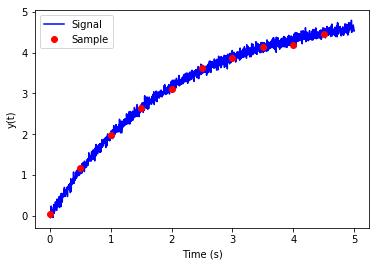

In [11]:
plt.plot(tspan, signal, label = "Signal", color = "blue")
plt.plot(sampletimes, samplevalues, "o", label = "Sample", color = "red")
plt.xlabel("Time (s)")
plt.ylabel("y(t)")
plt.legend(loc = "best")

In [12]:
u = numpy.ones_like(samplevalues)
u

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [13]:
samplevalues

array([0.0418532 , 1.17454744, 1.99140219, 2.65209348, 3.11669024,
       3.61464335, 3.8751928 , 4.13545389, 4.19202136, 4.46001541])

In [14]:
sampletimes

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5])

In [15]:
Y = []
X = []
for k in range(1, len(samplevalues)):
    Y.append([samplevalues[k]])
    X.append([samplevalues[k - 1], u[k]])
Y = numpy.array(Y)
X_1 = numpy.array(X)
X_1

array([[0.0418532 , 1.        ],
       [1.17454744, 1.        ],
       [1.99140219, 1.        ],
       [2.65209348, 1.        ],
       [3.11669024, 1.        ],
       [3.61464335, 1.        ],
       [3.8751928 , 1.        ],
       [4.13545389, 1.        ],
       [4.19202136, 1.        ]])

In [16]:
β1, _, _, _ = numpy.linalg.lstsq(X_1, Y)
β1

/Users/alchemyst/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  """Entry point for launching an IPython kernel.


array([[0.77295679],
       [1.11638315]])

In [17]:
Y = []
X = []
for k in range(2, len(samplevalues)):
    Y.append([samplevalues[k]])
    X.append([samplevalues[k - 1], samplevalues[k - 2], u[k - 1], u[k - 2]])
Y = numpy.array(Y)
X_2 = numpy.array(X)
X_2[0,1] = 0
X_2[0,3] = 0
X_2

array([[1.17454744, 0.        , 1.        , 0.        ],
       [1.99140219, 1.17454744, 1.        , 1.        ],
       [2.65209348, 1.99140219, 1.        , 1.        ],
       [3.11669024, 2.65209348, 1.        , 1.        ],
       [3.61464335, 3.11669024, 1.        , 1.        ],
       [3.8751928 , 3.61464335, 1.        , 1.        ],
       [4.13545389, 3.8751928 , 1.        , 1.        ],
       [4.19202136, 4.13545389, 1.        , 1.        ]])

In [18]:
β2, _, _, _ = numpy.linalg.lstsq(X_2, Y)
β2

/Users/alchemyst/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  """Entry point for launching an IPython kernel.


array([[-0.14152959],
       [ 0.70653134],
       [ 2.1576354 ],
       [-0.03524639]])

In [19]:
y1 = X_2[:,0]
y2 = X_2[:,1]
u1 = X_2[:,2]
u2 = X_2[:,3]

In [20]:
def discrete2(β, t):
    a1, a2, b1, b2 = β
    return a1*y1 + a2*y2 + b1*u1 + b2*u2

In [21]:
def discrete1(β, t):
    a1, b1 = β
    return a1*y1 + b1*u1 

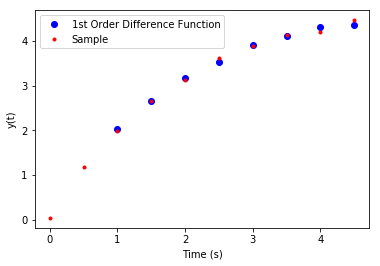

In [24]:
plt.plot(sampletimes[2:], discrete1(β1, sampletimes), "o", label = "1st Order Difference Function", color = "blue")
plt.plot(sampletimes, samplevalues, ".", label = "Sample", color = "red")
plt.xlabel("Time (s)")
plt.ylabel("y(t)")
plt.legend(loc = "best")

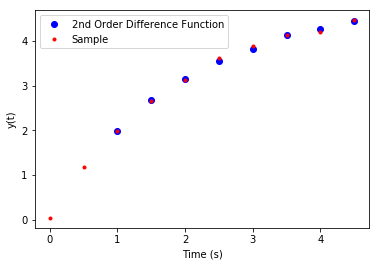

In [27]:
plt.plot(sampletimes[2:], discrete2(β2, sampletimes), "o", label = "2nd Order Difference Function", color = "blue")
plt.plot(sampletimes, samplevalues, ".", label = "Sample", color = "red")
plt.xlabel("Time (s)")
plt.ylabel("y(t)")
plt.legend(loc = "best")